Resolving data files:   0%|          | 0/54 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/108 [00:00<?, ?it/s]

Size of human dataset: 164
Size of AI dataset: 5361373


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at microsoft/codebert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch [1/5], Batch [0], Loss: 0.6877
Epoch [1/5], Batch [10], Loss: 1.3308
Epoch [1/5], Batch [20], Loss: 0.2664
Epoch [1/5], Batch [30], Loss: 0.6693
Epoch [1/5], Batch [40], Loss: 0.1219
Epoch [1/5], Batch [50], Loss: 0.1329
Epoch [1/5], Batch [60], Loss: 0.1339
Epoch [1/5], Batch [70], Loss: 0.1814
Epoch [1/5], Batch [80], Loss: 0.0166
Epoch [1/5], Batch [90], Loss: 0.2638
Epoch [1/5], Batch [100], Loss: 0.0068
Epoch [1/5], Batch [110], Loss: 0.0887
Epoch 1/5, Loss: 0.1877, Accuracy: 0.8700
Validation Loss: 0.0018, Validation Accuracy: 1.0000
Epoch [2/5], Batch [0], Loss: 0.0035
Epoch [2/5], Batch [10], Loss: 0.0933
Epoch [2/5], Batch [20], Loss: 0.0890
Epoch [2/5], Batch [30], Loss: 0.0908
Epoch [2/5], Batch [40], Loss: 0.0022
Epoch [2/5], Batch [50], Loss: 0.0009
Epoch [2/5], Batch [60], Loss: 0.0030
Epoch [2/5], Batch [70], Loss: 0.0021
Epoch [2/5], Batch [80], Loss: 0.0879
Epoch [2/5], Batch [90], Loss: 0.0026
Epoch [2/5], Batch [100], Loss: 0.0876
Epoch [2/5], Batch [110], Loss

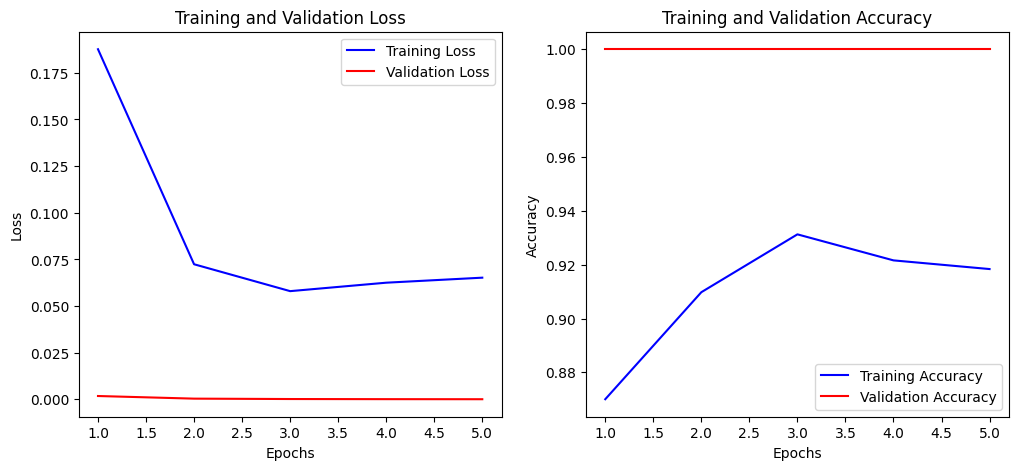

In [3]:
import torch
from torch import nn
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from torch.optim import AdamW
from datasets import load_dataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Step 1: Load the datasets
human_dataset = load_dataset("openai_humaneval", split="test")
ai_dataset = load_dataset("codeparrot/codeparrot-clean", split="train")

# Print dataset sizes
print(f"Size of human dataset: {len(human_dataset)}")
print(f"Size of AI dataset: {len(ai_dataset)}")

# Sample sizes
human_sample_size = min(1000, len(human_dataset))
ai_sample_size = min(1000, len(ai_dataset))

# Select subsets
human_dataset = human_dataset.select(range(human_sample_size))
ai_dataset = ai_dataset.select(range(ai_sample_size))

# Step 2: Preprocess datasets
tokenizer = RobertaTokenizer.from_pretrained("microsoft/codebert-base")

def preprocess_dataset(dataset, label, column_name):
    tokenized_samples = []
    labels = []
    attention_masks = []

    for code_sample in dataset[column_name]:
        tokenized_input = tokenizer(
            code_sample,
            padding='max_length',
            truncation=True,
            max_length=512,
            return_tensors='pt'
        )
        tokenized_samples.append(tokenized_input['input_ids'].squeeze(0))
        labels.append(label)
        attention_masks.append(tokenized_input['attention_mask'].squeeze(0))

    return tokenized_samples, labels, attention_masks

# Preprocess datasets
human_tokens, human_labels, human_attention_masks = preprocess_dataset(human_dataset, 0, 'canonical_solution')
ai_tokens, ai_labels, ai_attention_masks = preprocess_dataset(ai_dataset, 1, 'content')

# Combine datasets
tokens = human_tokens + ai_tokens
labels = human_labels + ai_labels
attention_masks = human_attention_masks + ai_attention_masks

# Convert to PyTorch tensors
tokens = torch.stack(tokens)
labels = torch.tensor(labels)
attention_masks = torch.stack(attention_masks)

# Step 3: Split the dataset into training and validation sets
X_train, X_val, y_train, y_val, masks_train, masks_val = train_test_split(tokens, labels, attention_masks, test_size=0.2, random_state=42)

# Create PyTorch Dataset and DataLoader
train_dataset = torch.utils.data.TensorDataset(X_train, y_train, masks_train)
val_dataset = torch.utils.data.TensorDataset(X_val, y_val, masks_val)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=8, shuffle=False)

# Step 4: Define the CodeBERT model with Dropout
class CodeBERTClassifier(nn.Module):
    def __init__(self):
        super(CodeBERTClassifier, self).__init__()
        self.model = RobertaForSequenceClassification.from_pretrained("microsoft/codebert-base", num_labels=2)
        self.dropout = nn.Dropout(p=0.3)  # Add a dropout layer

    def forward(self, input_ids, attention_mask=None):
        outputs = self.model(input_ids, attention_mask=attention_mask)
        logits = self.dropout(outputs.logits)  # Apply dropout
        return logits

# Initialize model
model = CodeBERTClassifier()

# Step 5: Define optimizer and loss function
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=1e-5)  # Weight decay for L2 regularization
loss_fn = nn.CrossEntropyLoss()

# Move model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Step 6: Training loop with early stopping
def train_model(model, train_loader, val_loader, optimizer, loss_fn, num_epochs=5, patience=3):
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    
    best_val_loss = float('inf')
    epochs_without_improvement = 0

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        correct_predictions = 0
        total_predictions = 0

        for batch_idx, batch in enumerate(train_loader):
            optimizer.zero_grad()
            input_ids, labels, attention_mask = batch[0].to(device), batch[1].to(device), batch[2].to(device)
            outputs = model(input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            # Get predictions
            _, preds = torch.max(outputs, dim=1)
            correct_predictions += torch.sum(preds == labels).item()
            total_predictions += labels.size(0)

            if batch_idx % 10 == 0:  # Print every 10 batches
                print(f"Epoch [{epoch + 1}/{num_epochs}], Batch [{batch_idx}], Loss: {loss.item():.4f}")

        avg_loss = total_loss / len(train_loader)
        accuracy = correct_predictions / total_predictions
        print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}")

        # Validation loop
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for batch in val_loader:
                input_ids, labels, attention_mask = batch[0].to(device), batch[1].to(device), batch[2].to(device)
                outputs = model(input_ids, attention_mask=attention_mask)
                loss = loss_fn(outputs, labels)
                val_loss += loss.item()
                _, preds = torch.max(outputs, dim=1)
                val_correct += torch.sum(preds == labels).item()
                val_total += labels.size(0)

        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = val_correct / val_total
        print(f"Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

        # Early stopping logic
        train_losses.append(avg_loss)
        val_losses.append(avg_val_loss)
        train_accuracies.append(accuracy)
        val_accuracies.append(val_accuracy)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping triggered after {epoch + 1} epochs.")
                break

    return train_losses, val_losses, train_accuracies, val_accuracies

# Train the model
train_losses, val_losses, train_accuracies, val_accuracies = train_model(model, train_loader, val_loader, optimizer, loss_fn, num_epochs=5)

# Step 7: Save the model
torch.save(model.state_dict(), 'E:/python-projects/llm/Trained_models/codebert_model.pth')
print("Model saved to 'E:/python-projects/llm/Trained_models/codebert_model.pth'")

# Step 8: Plot training and validation loss/accuracy
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, 'b', label='Training Loss')
plt.plot(epochs, val_losses, 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, 'b', label='Training Accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()
